In [1]:
!pip install pygal


     |████████████████████████████████| 133kB 6.5MB/s 


In [2]:
!pip install cairosvg

     |████████████████████████████████| 51kB 2.8MB/s 
     |████████████████████████████████| 71kB 3.9MB/s 
  Created wheel for cairocffi: filename=cairocffi-1.2.0-cp37-none-any.whl size=89548 sha256=338e482ce4e486bac324f39b9c23e8a5c716c96c955784b2bd820e7ab2117c44
  Stored in directory: /root/.cache/pip/wheels/40/76/48/f1effadceea83b32e7d957dd0f92db4db8b537d7b72b4ef374
Successfully built cairocffi


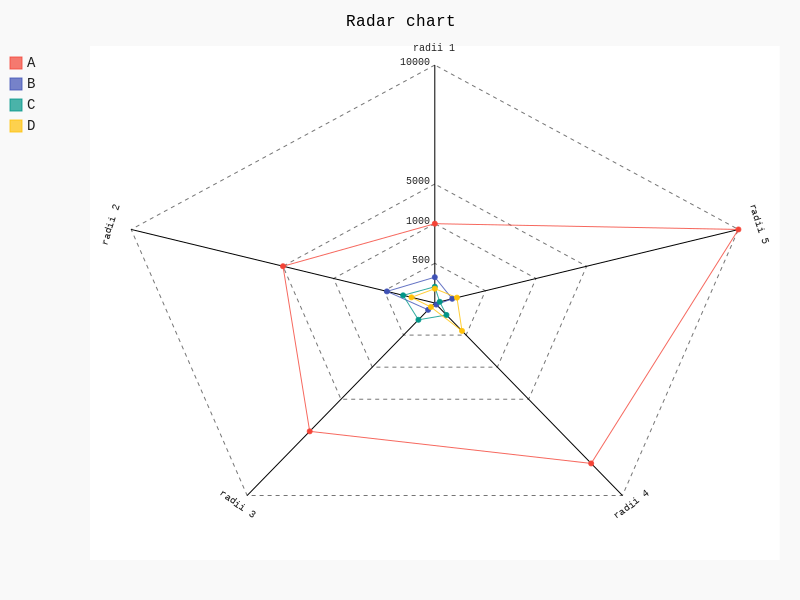

In [3]:
# importing pygal 
import pygal 
import numpy 
  
  
# creating the chart object 
radar_chart = pygal.Radar() 
  
# naming the title 
radar_chart.title = 'Radar chart'
  
radar_chart.x_labels = ['radii 1', 'radii 2', 
                        'radii 3', 'radii 4', 
                        'radii 5'] 
# radar_chart.y_labels = ['y 1', 'y 2', 
#                         'y 3', 'y 4', 
#                         'y 5'] 
radar_chart.y_labels = [{
            'label': '500',
            'value': 1
        }, {
            'label': '1000',
            'value': 2
        }, {
            'label': '5000',
            'value': 3
        }, {
            'label': '10000',
            'value': 6
        }]
# Random data 
radar_chart.add('A', [2, 3, 4, 5, 6]) 
radar_chart.add('B', numpy.random.rand(5)) 
radar_chart.add('C', numpy.random.rand(5)) 
radar_chart.add('D', numpy.random.rand(5)) 
  
radar_chart

In [ ]:
# -*- coding: utf-8 -*-
import pygal

radar_chart = pygal.Radar()
radar_chart.title = 'Product Budget Figures'
radar_chart.x_labels = ['Sales', 'Marketing', 'Development', 'Customer support', 'Information Technology', 'Administration']
radar_chart.y_labels = [{'label':'y 1', 'value': 20},
                        'y 2', 
                        'y 3', 'y 4', 
                        'y 5']

radar_chart.add('Estimate', [40, 20, 100, 20, 30, 20, 10])
radar_chart.add('Actual Spending', [70, 50, 40, 10, 17, 8, 10])
radar_chart.render_to_file('radar_chart.svg')

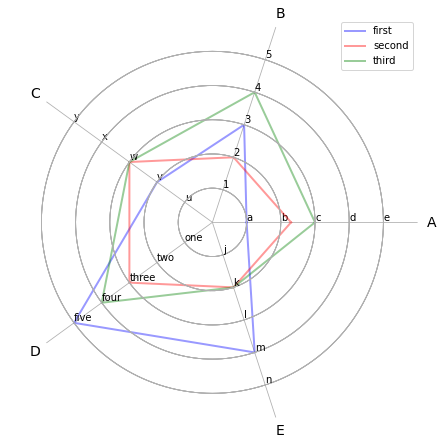

In [ ]:
import numpy as np
import pylab as pl

# Python 3.4
# matplotlib 1.5.3
class Radar(object):
    def __init__(self, fig, titles, labels, rotation=0, rect=None):
        if rect is None:
            rect = [0.05, 0.05, 0.95, 0.95]

        self.n = len(titles)
        self.angles = np.arange(0, 360, 360.0/self.n)
        self.axes = [fig.add_axes(rect, projection="polar", label="axes%d" % i) 
                         for i in range(self.n)]

        self.ax = self.axes[0]
        self.ax.set_thetagrids(self.angles, labels=titles, fontsize=14)

        for ax in self.axes[1:]:
            ax.patch.set_visible(False)
            ax.grid("off")
            ax.xaxis.set_visible(False)

        for ax, angle, label in zip(self.axes, self.angles, labels):
            ax.set_rgrids(range(1, 6), angle=angle, labels=label)
            ax.spines["polar"].set_visible(False)
            ax.set_ylim(0, 6)
            ax.set_theta_offset(np.deg2rad(rotation))

    def plot(self, values, *args, **kw):
        angle = np.deg2rad(np.r_[self.angles, self.angles[0]])
        values = np.r_[values, values[0]]
        self.ax.plot(angle, values, *args, **kw)



fig = pl.figure(figsize=(6, 6))

titles = list("ABCDE")

labels = [
    list("abcde"), list("12345"), list("uvwxy"), 
    ["one", "two", "three", "four", "five"],
    list("jklmn")
]

radar = Radar(fig, titles, labels)
radar.plot([1, 3, 2, 5, 4],  "-", lw=2, color="b", alpha=0.4, label="first")
radar.plot([2.3, 2, 3, 3, 2],"-", lw=2, color="r", alpha=0.4, label="second")
radar.plot([3, 4, 3, 4, 2], "-", lw=2, color="g", alpha=0.4, label="third")
radar.ax.legend()
fig.savefig('radar.svg')